In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import pandas as pd

In [2]:
df = pd.read_csv("serie_temporal_realista.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Data    100 non-null    object 
 1   Valor   100 non-null    float64
dtypes: float64(1), object(1)
memory usage: 1.7+ KB


In [5]:
df["Data"] = pd.to_datetime(df["Data"])

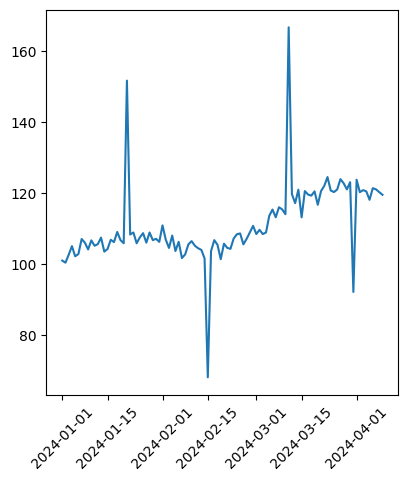

In [8]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.xticks(rotation=45)
plt.plot(df["Data"], df["Valor"])

In [11]:
result = adfuller(df["Valor"])
print(result)

(-1.9652336586467345, 0.3020218125326505, 4, 95, {'1%': -3.5011373281819504, '5%': -2.8924800524857854, '10%': -2.5832749307479226}, 652.2973833293512)


In [ ]:
# Quanto mais negativo "mais estacionária"
print("Teste Estatistico ADF", result[0])

Teste Estatistico ADF -1.9652336586467345


In [ ]:
# Interpretação direta, esse que é usado na verificação da estacionáriedade
print("p-value", result[1])

p-value 0.3020218125326505


In [14]:
print("Número de Lags", result[2])

Número de Lags 4


In [15]:
print("Valores criticos", result[4])

Valores criticos {'1%': -3.5011373281819504, '5%': -2.8924800524857854, '10%': -2.5832749307479226}


In [16]:
print("IC", result[5])

IC 652.2973833293512


In [ ]:
adf_stat, p_value, lags, n_obs, crit_values, ic_best = result

In [19]:
def adf_test(series):
    result = adfuller(series)
    print(f"p-value: {result[1]}")

    if result[1] <= 0.05:
        print("Rejeito a Hipotese Nula, a série é estacionária")
    else:
        print("Não rejeito a hipotese nula, a série não é estacionária") 

adf_test(df["Valor"])

p-value: 0.3020218125326505
Não rejeito a hipotese nula, a série não é estacionária
